# L- aze: Value and Policy Iteration

## Installation and Setup

You need:
* Gymnasium
* Patched `gym-classics-1.0.0+internal.rev1` or later

In [3]:
import numpy as np
np.set_printoptions(precision=2)

In [4]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

from gym_classics.utils import print_gridworld
from gym_classics.animation import gridworld_animate

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/common/gym-classics/gym_classics/__init__.py:75: UserWarning: gym-classics environments were already registered for gymnasium; additional calls to `register()` are ignored.
  warnings.warn("gym-classics environments were already registered for {}; "


## Define the L Maze

In [5]:
from gym_classics.envs.abstract.noisy_gridworld import Gridworld

class LMazeGridworld(Gridworld):
    layout = """
|        |
|      G |
|        |
| XXXXX  |
|     X  |
|     X  |
|     X  |
|     X  |
| S   X  |
|        |
"""

    def __init__(self):
        super().__init__(self.layout)

    def _reward(self, state, action, next_state):
        return {(6, 8): +1.0}.get(state, 0.0)

    def _done(self, state, action, next_state):
        return state in self._goals  

gym.register('LMaze-v0', entry_point=LMazeGridworld)

We can use `make()` to create registered environments. Gymnasium uses wrappers, so we have unwrap the environment first to get the extended model API.

In [6]:
gym_env = gym.make('LMaze-v0')
env = gym_env.unwrapped

Visualize the layout with state ids.

States: range(0, 70)


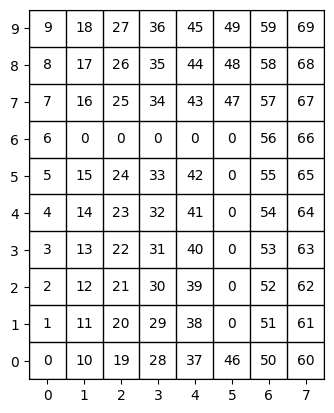

In [7]:
print("States:", env.states())
env.image()

## Value Iteration

In [8]:
from gym_classics.algorithms import value_iteration, greedy_policy

V_star = value_iteration(env, discount=.8, verbose=True)

................
Converged after 16 sweeps.


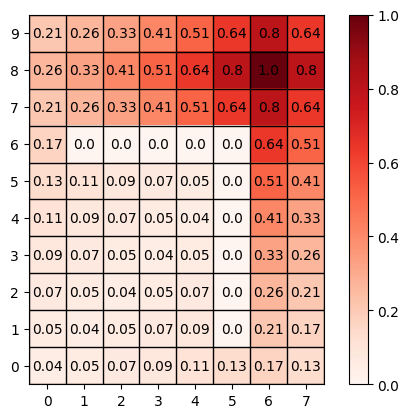

In [9]:
env.image(V_star, labels=True, cmap ="Reds")

Find the optimal policy given the optimal value function.

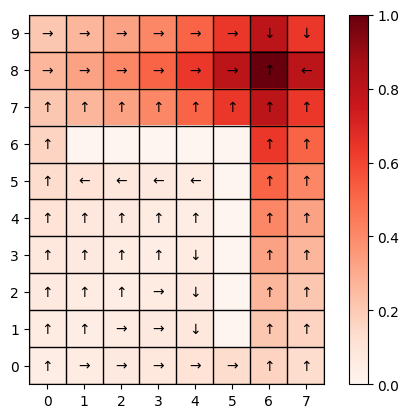

In [10]:
pol_star = greedy_policy(env, V_star)
env.image(V_star, policy=pol_star, cmap = "Reds")

In [11]:
Vs = value_iteration(env, discount=.8, precision=0.1, history=True, verbose=True)
Vs

#gridworld_image_list(env, Vs, cmap = "Reds")

............
Converged after 12 sweeps.


[array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.]),
 array([0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 1.  , 0.8 , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.8 , 0.64]),
 array([0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.

In [12]:
gridworld_animate(env, Vs, cmap = "Reds")

## Policy Iteration


.......
Converged after 7 iterations.


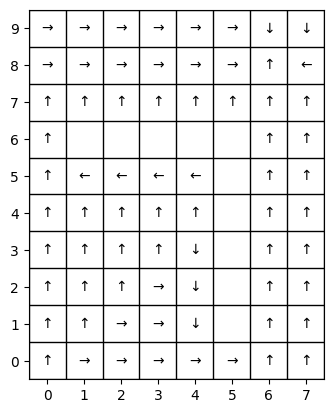

In [13]:
from gym_classics.algorithms import policy_iteration

pol_star = policy_iteration(env, discount=.8, verbose=True)

env.image(policy=pol_star)

In [14]:

policy_list, V_list = policy_iteration(env, discount=.8, history=True, verbose=True)

#gridworld_image_list(env, V_list, policies=policy_list, cmap = "Reds")

........
Converged after 8 iterations.


In [15]:
gridworld_animate(env, V_list, policies = policy_list, cmap = "Reds")


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)